## CSV 6: Multi-Currency Sales (No Normalization)

**Description**  
A global sales transactions dataset with revenue recorded in local currencies and no exchange-rate normalization. Identical products appear across regions with vastly different nominal currency values.

**Purpose / What It Tests**
- Detection and handling of multi-currency data
- Prevention of incorrect direct revenue aggregation
- Explicit warnings and clarification around base currency
- Transparency of financial assumptions
- Trust and reasoning quality over raw computation


Dataset Generation

In [1]:
import pandas as pd
import numpy as np
import random
from datetime import datetime, timedelta

np.random.seed(77)

N_ROWS = 2600

start_date = datetime(2023, 1, 1)
end_date = datetime(2024, 12, 31)

def random_date():
    return start_date + timedelta(days=random.randint(0, (end_date - start_date).days))

products = [
    (101, "CRM Pro", "Software"),
    (102, "Analytics Suite", "Software"),
    (201, "POS Terminal", "Hardware"),
]

regions = [
    ("North America", "USD"),
    ("Europe", "EUR"),
    ("UK", "GBP"),
    ("Japan", "JPY"),
    ("Pakistan", "PKR"),
]

salespeople = [f"Salesperson_{i}" for i in range(1, 10)]

rows = []

for i in range(N_ROWS):
    product_id, product_name, category = random.choice(products)
    region, currency = random.choice(regions)

    units = random.randint(1, 20)

    # Price scales by currency realism
    base_price_usd = random.randint(200, 2000)

    currency_multiplier = {
        "USD": 1,
        "EUR": 0.95,
        "GBP": 0.8,
        "JPY": 150,
        "PKR": 280,
    }

    local_price = int(base_price_usd * currency_multiplier[currency])
    revenue = units * local_price

    rows.append({
        "order_id": f"O-{600000+i}",
        "order_date": random_date(),
        "product_id": product_id,
        "product_name": product_name,
        "category": category,
        "units": units,
        "revenue": revenue,          # 🚨 NOT normalized
        "currency": currency,        # ✅ present but dangerous
        "region": region,
        "salesperson": random.choice(salespeople),
        "stage": "Won"
    })

df = pd.DataFrame(rows)

df.to_csv("sales_multicurrency.csv", index=False)
print("CSV generated: sales_multicurrency.csv")


CSV generated: sales_multicurrency.csv


Validation Code

In [2]:
import pandas as pd

df = pd.read_csv("sales_multicurrency.csv")

# Confirm multiple currencies exist
currency_counts = df["currency"].value_counts()
print("Currency distribution:\n", currency_counts)

assert df["currency"].nunique() > 3, "❌ Not enough currency diversity"

# Compare average revenue per order by currency
avg_revenue_by_currency = df.groupby("currency")["revenue"].mean()
print("\nAverage revenue by currency:\n", avg_revenue_by_currency)

# Ratio check (should be extreme)
ratio = avg_revenue_by_currency.max() / avg_revenue_by_currency.min()
print("\nMax/Min revenue ratio across currencies:", ratio)

assert ratio > 50, "❌ Currency scale differences not significant"

print("✅ Multi-currency risk conditions validated.")


Currency distribution:
 currency
GBP    538
EUR    534
PKR    523
USD    520
JPY    485
Name: count, dtype: int64

Average revenue by currency:
 currency
EUR    1.108194e+04
GBP    9.181310e+03
JPY    1.763875e+06
PKR    3.348130e+06
USD    1.118345e+04
Name: revenue, dtype: float64

Max/Min revenue ratio across currencies: 364.6679574126558
✅ Multi-currency risk conditions validated.


Gold Truth Analysis

Total Revenue (USD): 30515366.394

Revenue by currency (USD):
 currency
EUR    6391178.640
GBP    6273222.150
JPY    5731711.980
PKR    6303858.624
USD    5815395.000
Name: revenue_usd, dtype: float64


C:\Users\KRONOS\AppData\Local\Temp\ipykernel_68756\3432964809.py:34: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M")["revenue_usd"]


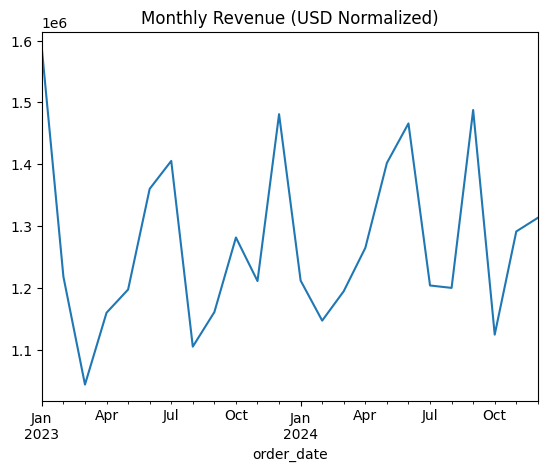

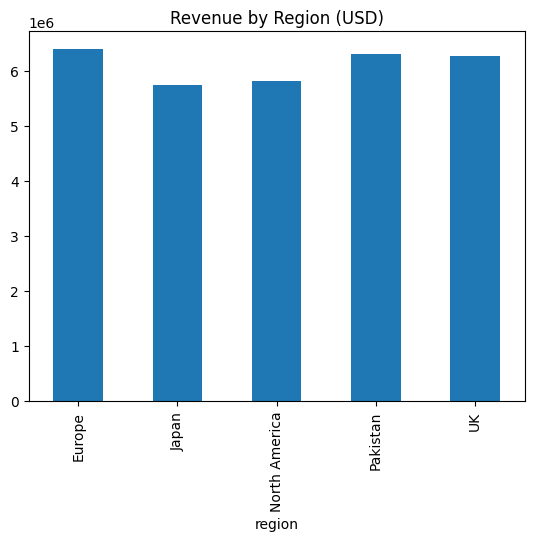

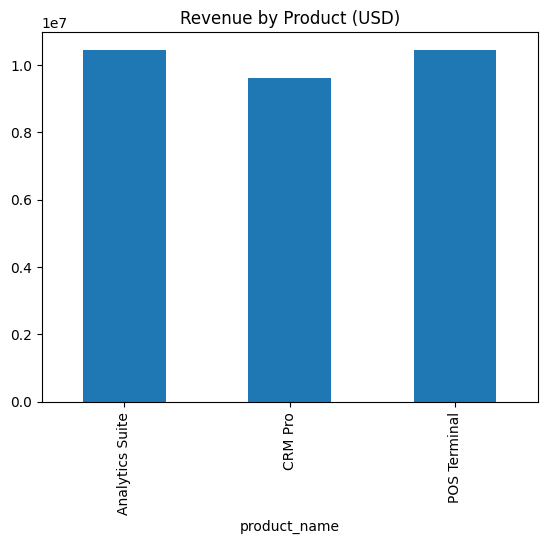

Average Order Value (USD): 11736.679382307693

Units sold by currency:
 currency
EUR    5591
GBP    5659
JPY    5168
PKR    5517
USD    5356
Name: units, dtype: int64


In [3]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("sales_multicurrency.csv", parse_dates=["order_date"])

exchange_rates = {
    "USD": 1.0,
    "EUR": 1.08,
    "GBP": 1.27,
    "JPY": 0.0067,
    "PKR": 0.0036,
}

# Normalize revenue to USD
df["revenue_usd"] = df["revenue"] * df["currency"].map(exchange_rates)

# ---------------------------
# KPI 1: Total Revenue (USD)
# ---------------------------
total_revenue_usd = df["revenue_usd"].sum()
print("Total Revenue (USD):", total_revenue_usd)

# ---------------------------
# KPI 2: Revenue Share by Currency (USD-normalized)
# ---------------------------
currency_share = df.groupby("currency")["revenue_usd"].sum()
print("\nRevenue by currency (USD):\n", currency_share)

# ---------------------------
# Trend 1: Monthly Revenue (USD)
# ---------------------------
monthly_revenue = (
    df.set_index("order_date")
      .resample("M")["revenue_usd"]
      .sum()
)

monthly_revenue.plot(title="Monthly Revenue (USD Normalized)")
plt.show()

# ---------------------------
# Trend 2: Revenue by Region (USD)
# ---------------------------
region_revenue = df.groupby("region")["revenue_usd"].sum()
region_revenue.plot(kind="bar", title="Revenue by Region (USD)")
plt.show()

# ---------------------------
# Trend 3: Revenue by Product (USD)
# ---------------------------
product_revenue = df.groupby("product_name")["revenue_usd"].sum()
product_revenue.plot(kind="bar", title="Revenue by Product (USD)")
plt.show()

# ---------------------------
# Trend 4: Average Order Value (USD)
# ---------------------------
avg_order_value = df["revenue_usd"].mean()
print("Average Order Value (USD):", avg_order_value)

# ---------------------------
# KPI 3: Units Sold by Currency
# ---------------------------
units_by_currency = df.groupby("currency")["units"].sum()
print("\nUnits sold by currency:\n", units_by_currency)
